Satellite Digital Twin
SHAP Explainability Analysis

Sample Telemetry


,Timestamp (UTC),OrbitPhase (%),Sunlight (0 or 1),BusVoltage (V),BusCurrent (A),BatteryVoltage (V),BatteryTemperature (°C),BatterySOC (%),SolarVoltage (V),SolarCurrent (A),WheelRPM (RPM),WheelTemperature (°C),CPUUsage (%),CPUTemperature (°C),SignalStrength (dBm),GyroMagnitude (deg/s),Altitude (km),FaultLabel
0,2026-01-01T00:00:00Z,0.0,1,32.756,12.44,7.543,30.12,65.0,21.69,3.76,-1.0,24.1,30.1,42.959,-98.0,0.028,550.11,0



Prediction
Fault       : Battery Degradation
Confidence  : 95.39 %

Class Probabilities


,Fault Class,Probability (%)
1,Battery Degradation,95.39
4,Reaction Wheel Fault,4.46
0,Normal,0.08
6,Thermal Fault,0.06
2,Communication Fault,0.00
3,Power Anomaly,0.00
5,Sensor Fault,0.00



Top SHAP Features


,Feature,Impact,Absolute Impact
0,BusVoltage (V),8.17133,8.17133
1,WheelRPM (RPM),-0.39762,0.39762
2,CPUUsage (%),0.34941,0.34941
3,GyroMagnitude (deg/s),-0.27316,0.27316
4,WheelTemperature (°C),-0.12519,0.12519
5,BusCurrent (A),0.10018,0.10018
6,SignalStrength (dBm),-0.09370,0.09370
7,BatterySOC (%),-0.02452,0.02452
8,CPUTemperature (°C),-0.02330,0.02330
9,OrbitPhase (%),-0.00990,0.00990


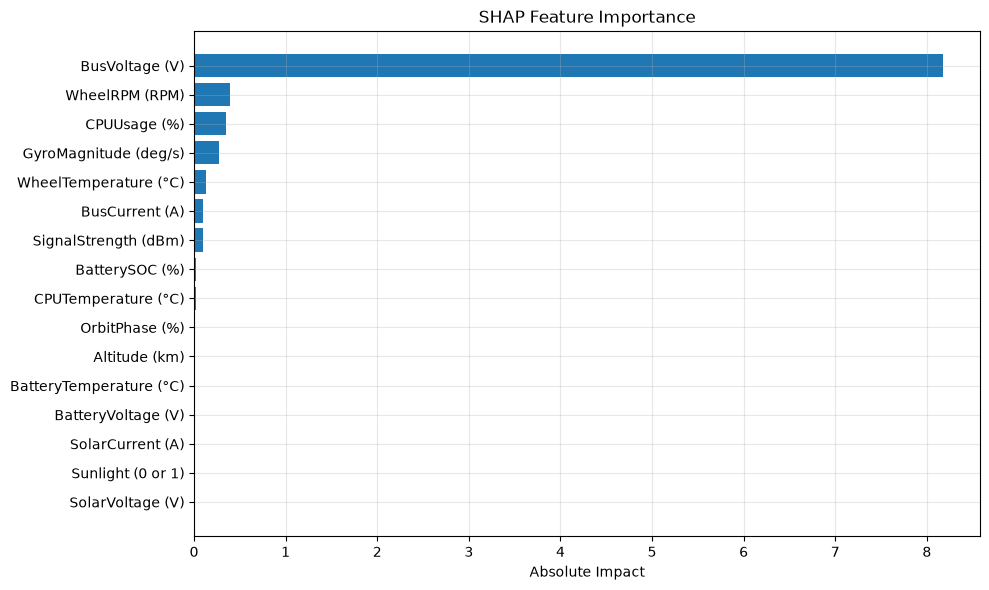

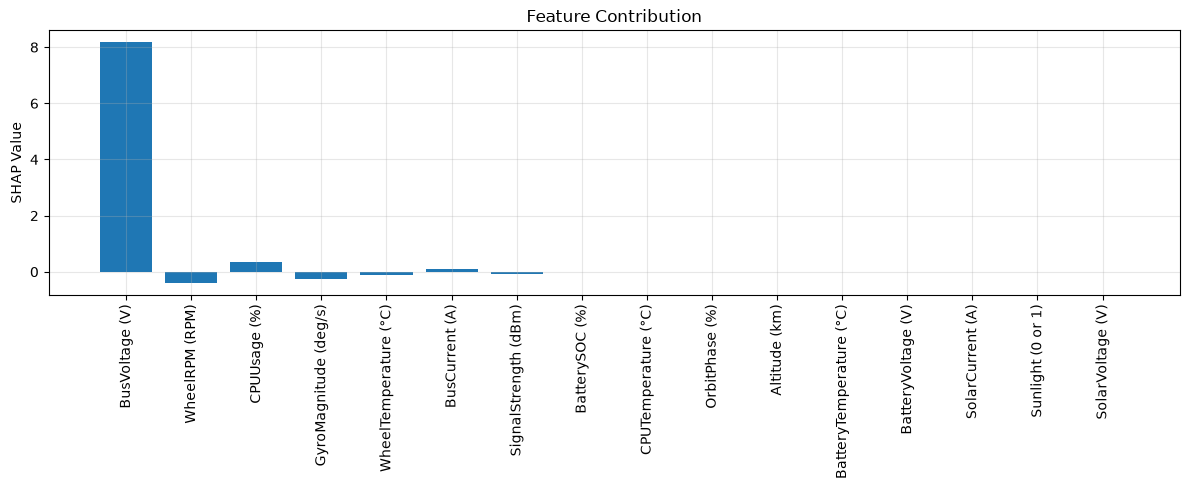

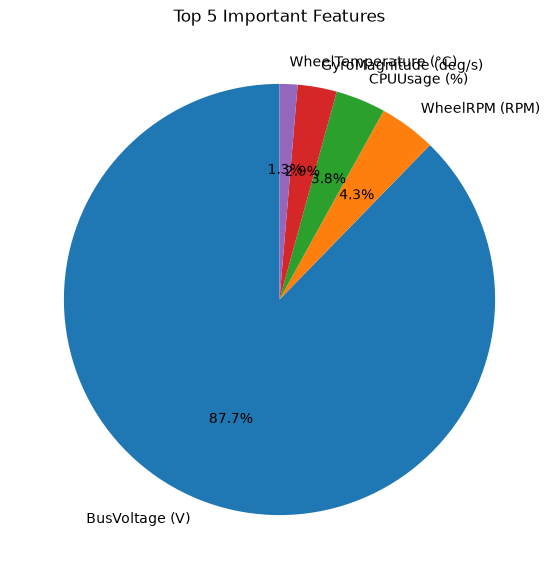


CSV Report Saved
C:\Users\hp\OneDrive\Documents\Satellite-Digital-Twin\backend\reports\shap_feature_importance.csv

Notebook Completed Successfully.


In [1]:
# ==========================================================
# Satellite Digital Twin
# Notebook 06 - SHAP Explainability
# ==========================================================

from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.data.dataset import load_demo_original
from src.models.predictor import Predictor
from src.explainability.shap_explainer import shap_explainer

print("=" * 70)
print("Satellite Digital Twin")
print("SHAP Explainability Analysis")
print("=" * 70)

# ----------------------------------------------------------
# Load Demo Sample
# ----------------------------------------------------------

demo = load_demo_original()

sample = demo.iloc[[0]]

print("\nSample Telemetry")

display(sample)

# ----------------------------------------------------------
# Prediction
# ----------------------------------------------------------

predictor = Predictor()

prediction = predictor.predict(sample)

print("\nPrediction")

print(f"Fault       : {prediction['fault_name']}")
print(f"Confidence  : {prediction['confidence']} %")

print("\nClass Probabilities")

display(
    pd.DataFrame(
        prediction["probabilities"].items(),
        columns=["Fault Class", "Probability (%)"]
    ).sort_values(
        "Probability (%)",
        ascending=False
    )
)

# ----------------------------------------------------------
# SHAP Explanation
# ----------------------------------------------------------

result = shap_explainer.explain(sample)

importance = pd.DataFrame(
    result["all_features"]
)

importance.rename(
    columns={
        "feature":"Feature",
        "impact":"Impact",
        "absolute_impact":"Absolute Impact"
    },
    inplace=True
)

print("\nTop SHAP Features")

display(importance.head(10))

# ----------------------------------------------------------
# Horizontal Bar Chart
# ----------------------------------------------------------

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Absolute Impact"]
)

plt.gca().invert_yaxis()

plt.title("SHAP Feature Importance")

plt.xlabel("Absolute Impact")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# Contribution Chart
# ----------------------------------------------------------

plt.figure(figsize=(12,5))

plt.bar(
    importance["Feature"],
    importance["Impact"]
)

plt.xticks(rotation=90)

plt.ylabel("SHAP Value")

plt.title("Feature Contribution")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# ----------------------------------------------------------
# Pie Chart
# ----------------------------------------------------------

top5 = importance.head(5)

plt.figure(figsize=(7,7))

plt.pie(
    top5["Absolute Impact"],
    labels=top5["Feature"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Important Features")

plt.show()

# ----------------------------------------------------------
# Export Results
# ----------------------------------------------------------

REPORT_DIR = PROJECT_ROOT / "reports"

REPORT_DIR.mkdir(exist_ok=True)

importance.to_csv(
    REPORT_DIR / "shap_feature_importance.csv",
    index=False
)

print("\nCSV Report Saved")

print(REPORT_DIR / "shap_feature_importance.csv")

print("\nNotebook Completed Successfully.")